#EDA


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
# --- 1. Carga de datos ---
clientes = pd.read_csv('train_clientes_sample.csv')
requerimientos = pd.read_csv('train_requerimientos_sample.csv')

In [3]:
# --- 2. EDA básico clientes ---
print("Clientes - info y nulos")
print(clientes.info())
print("\nClientes - estadísticos descriptivos")
print(clientes.describe(include='all'))

Clientes - info y nulos
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 53 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID_CORRELATIVO             56000 non-null  int64  
 1   CODMES                     56000 non-null  int64  
 2   FLG_BANCARIZADO            56000 non-null  int64  
 3   RANG_INGRESO               48450 non-null  object 
 4   FLAG_LIMA_PROVINCIA        53277 non-null  object 
 5   EDAD                       51747 non-null  float64
 6   ANTIGUEDAD                 54599 non-null  float64
 7   ATTRITION                  56000 non-null  int64  
 8   RANG_SDO_PASIVO_MENOS0     56000 non-null  object 
 9   SDO_ACTIVO_MENOS0          56000 non-null  int64  
 10  SDO_ACTIVO_MENOS1          56000 non-null  int64  
 11  SDO_ACTIVO_MENOS2          56000 non-null  int64  
 12  SDO_ACTIVO_MENOS3          56000 non-null  int64  
 13  SDO_ACTIVO_MENOS4     

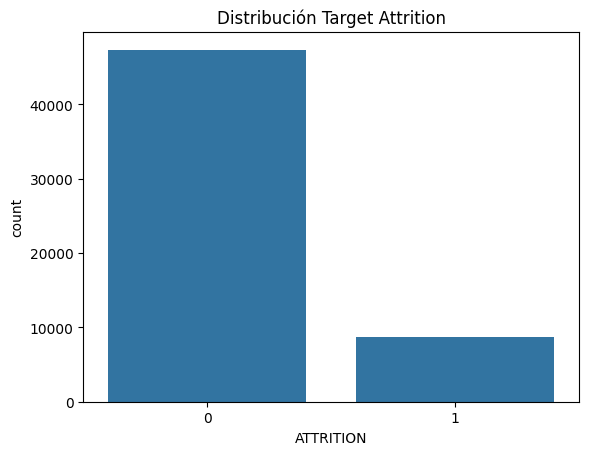

In [4]:
# Distribución target (si tienes variable target en clientes)
if 'ATTRITION' in clientes.columns:
    sns.countplot(x='ATTRITION', data=clientes)
    plt.title('Distribución Target Attrition')
    plt.show()


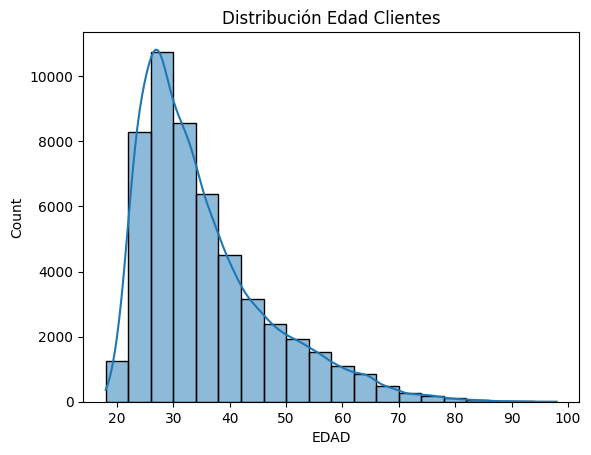

In [5]:
# Ejemplo distribución edad
sns.histplot(clientes['EDAD'].dropna(), bins=20, kde=True)
plt.title('Distribución Edad Clientes')
plt.show()


In [6]:
# --- 3. EDA básico requerimientos ---
print("\nRequerimientos - info y nulos")
print(requerimientos.info())

print("\nTipos de requerimiento")
print(requerimientos['TIPO_REQUERIMIENTO2'].value_counts())

print("\nDictamen")
print(requerimientos['DICTAMEN'].value_counts())



Requerimientos - info y nulos
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41313 entries, 0 to 41312
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID_CORRELATIVO       41313 non-null  int64 
 1   TIPO_REQUERIMIENTO2  41313 non-null  object
 2   DICTAMEN             41312 non-null  object
 3   CODMES               41313 non-null  int64 
 4   PRODUCTO_SERVICIO_2  41313 non-null  object
 5   SUBMOTIVO_2          41313 non-null  object
dtypes: int64(2), object(4)
memory usage: 1.9+ MB
None

Tipos de requerimiento
TIPO_REQUERIMIENTO2
Reclamo      30021
Solicitud    11292
Name: count, dtype: int64

Dictamen
DICTAMEN
PROCEDE TOTAL      20224
NO PROCEDE         19047
PROCEDE PARCIAL     2041
Name: count, dtype: int64


In [7]:
# --- 4. Agregación variables transaccionales ---
# Total requerimientos por cliente
total_reqs = requerimientos.groupby('ID_CORRELATIVO').size().rename('TOTAL_REQUERIMIENTOS')

# Total reclamos
total_reclamos = requerimientos[requerimientos['TIPO_REQUERIMIENTO2'] == 'Reclamo'] \
                .groupby('ID_CORRELATIVO').size().rename('TOTAL_RECLAMOS')

# Porcentaje reclamos / total requerimientos
porc_reclamos = (total_reclamos / total_reqs).fillna(0).rename('PORC_RECLAMOS')

# Dictamen procede (cuántos 'PROCEDE' vs total)
dictamen_procede = requerimientos[requerimientos['DICTAMEN'].str.upper() == 'PROCEDE'] \
                    .groupby('ID_CORRELATIVO').size().rename('TOTAL_PROCDE')

porc_procede = (dictamen_procede / total_reqs).fillna(0).rename('PORC_PROCDE')

# Requerimientos promedio por mes (contar meses activos)
meses_activos = requerimientos.groupby('ID_CORRELATIVO')['CODMES'].nunique().rename('MESES_ACTIVOS')

req_prom_mes = (total_reqs / meses_activos).fillna(0).rename('REQ_PROM_MES')

# Concatenar todas las variables nuevas
req_agg = pd.concat([
    total_reqs, total_reclamos, porc_reclamos,
    dictamen_procede, porc_procede,
    meses_activos, req_prom_mes
], axis=1).fillna(0)


In [8]:
# --- 5. Unir con clientes ---
df = clientes.merge(req_agg, on='ID_CORRELATIVO', how='left').fillna(0)


In [13]:
# --- 6. Limpieza e imputación básica ---
# Reemplazar valores nulos en variables categóricas
categorical_cols = ['RANG_INGRESO', 'FLAG_LIMA_PROVINCIA', 'RANG_SDO_PASIVO_MENOS0', 'RANG_NRO_PRODUCTOS_MENOS0']
for col in categorical_cols:
    if col in df.columns:
        # Convert to string type before filling NaN
        df[col] = df[col].astype(str).fillna('Desconocido')

# Reemplazar nulos en numéricas con mediana
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
for col in numerical_cols:
    # Check if the column actually has NaNs before filling
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

In [14]:
# --- 7. Encoding simple ---
label_encoders = {}
# Use the same categorical columns list as in the cleaning step
categorical_cols_to_encode = ['RANG_INGRESO', 'FLAG_LIMA_PROVINCIA', 'RANG_SDO_PASIVO_MENOS0', 'RANG_NRO_PRODUCTOS_MENOS0']
for col in categorical_cols_to_encode:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str)) # Ensure column is string type before encoding
        label_encoders[col] = le

In [15]:
# --- 8. Preparar dataset para modelado ---
# Definir X, y
if 'ATTRITION' in df.columns:
    X = df.drop(columns=['ID_CORRELATIVO', 'CODMES', 'ATTRITION'])
    y = df['ATTRITION']
else:
    X = df.drop(columns=['ID_CORRELATIVO', 'CODMES'])
    y = None

# Dividir en train y test (si target existe)
if y is not None:
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)
    print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
else:
    X_train, X_test, y_train, y_test = X, None, None, None

# --- Listo para modelar ---
print("Dataset preparado para modelado.")
print(X_train.head())

Train size: (39200, 57), Test size: (16800, 57)
Dataset preparado para modelado.
       FLG_BANCARIZADO  RANG_INGRESO  FLAG_LIMA_PROVINCIA  EDAD  ANTIGUEDAD  \
53625                1             7                    1  43.0         1.0   
6377                 1             5                    1  26.0         2.0   
4116                 1             3                    1  39.0         0.0   
33457                1             2                    2  30.0         0.0   
36035                1             6                    1  77.0         5.0   

       RANG_SDO_PASIVO_MENOS0  SDO_ACTIVO_MENOS0  SDO_ACTIVO_MENOS1  \
53625                       0                  0                  0   
6377                        1                  0                  0   
4116                        1                  0                  0   
33457                       1                  0                  0   
36035                       6                140                  0   

       SDO_ACTIVO

In [16]:
# --- Exportar a CSV ---
df.to_csv('train_clientes_features_eda.csv', index=False)

#EDA Auto


In [17]:
!pip install setuptools #instalación de paquetes y dependencias
!pip install --upgrade ydata-profiling
!pip install ipywidgets


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.1/400.1 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 687.8/687.8 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.8 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=bd5274050358560da8f2593c0b948587e1f5b1667af4e19d38c4d4e65960dac7
  Stored in directory: /root/.cache/pip/wheels/8d/55/1a/19cd535375ed1ede0c996405ebffe34b196d78e2d9545723a2
Successfully built htmlmin
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.3 MB/s eta 0:00:00


In [18]:
import pandas as pd
import webbrowser
from ydata_profiling import ProfileReport
report = ProfileReport(df, title='EDA automático')
report_file = 'reporte_train_clientes_features.html'
report.to_file(report_file)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 60/60 [00:02<00:00, 23.87it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]